In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.pipeline import Pipeline
from sklearn.cluster import KMeans
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.decomposition import PCA
from sklearn.neighbors import LocalOutlierFactor

from mlxtend.frequent_patterns import apriori, association_rules
from mlxtend.preprocessing import TransactionEncoder

<h1>a. Clusterização: Use um algoritmo de clusterização para identificar grupos de casas com características semelhantes.</h1>

<h2>Preparação e Tratamento de Dados</h2>

In [2]:
# Carregar o dataset
df = pd.read_csv("Data/train.csv")

features = ['GrLivArea', 'OverallQual', 'GarageArea', 'TotalBsmtSF', 'YearBuilt', '1stFlrSF']

X = df[features].dropna()

<h2>Aplicação da Técnica de Clusterização</h2>

In [3]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

wcss = []  # Within-Cluster Sum of Square
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

<h2>Exibição Resultado</h2>

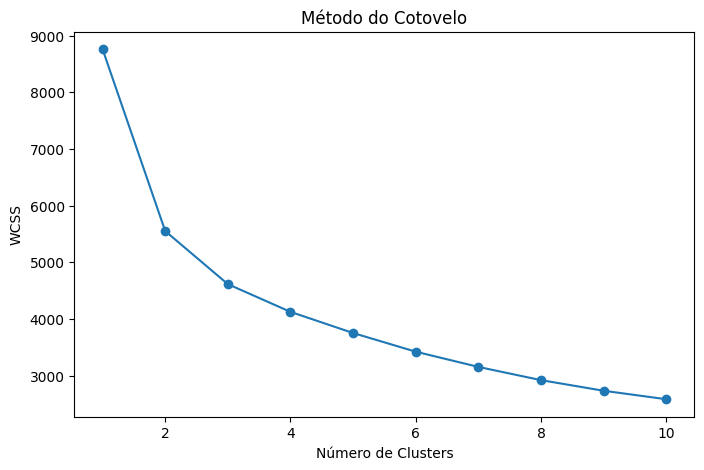

In [4]:
plt.figure(figsize=(8,5))
plt.plot(range(1,11), wcss, marker='o')
plt.title('Método do Cotovelo')
plt.xlabel('Número de Clusters')
plt.ylabel('WCSS')
plt.show()

<p>A gráfico gerado motra o ponto de inflexão por volta de 3 ou 4 clusters, que são geralmente os números mais indicados quando há uma queda significativa no WCSS.</p>

<h2>Aplicação com 4 clusters</h2>

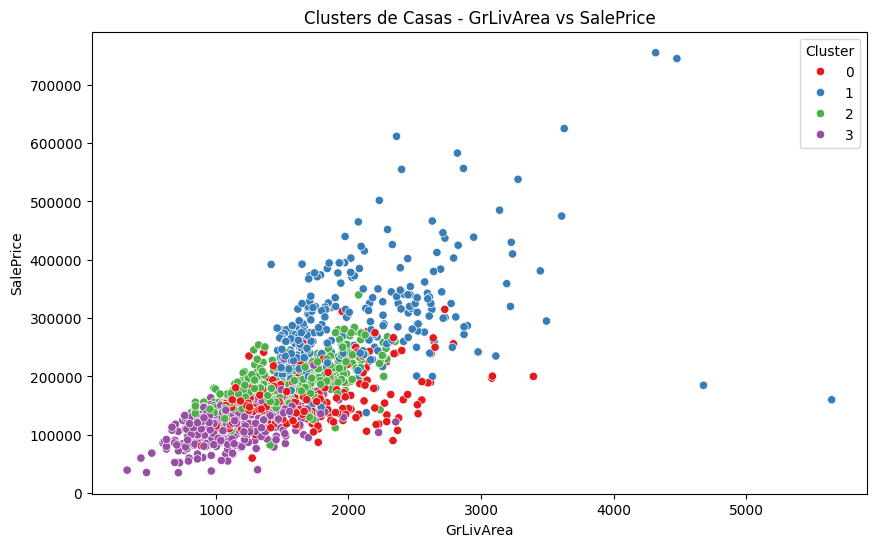

In [5]:
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_scaled)

X['Cluster'] = clusters

X['SalePrice'] = df.loc[X.index, 'SalePrice']

plt.figure(figsize=(10,6))
sns.scatterplot(x=X['GrLivArea'], y=X['SalePrice'], hue=X['Cluster'], palette='Set1')
plt.title('Clusters de Casas - GrLivArea vs SalePrice')
plt.xlabel('GrLivArea')
plt.ylabel('SalePrice')
plt.show()

<p>A análise de clusterização revelou a existência de quatro grupos bem definidos de casas, que se diferenciam principalmente pela área construída acima do solo (GrLivArea) e pelo preço de venda (SalePrice).</p>
<p>Observa-se uma relação positiva clara entre área e preço: à medida que a área construída aumenta, o preço das casas também tende a subir, embora com dispersões em alguns grupos.</p>
<p>O Cluster azul (Cluster 1) concentra as casas com as maiores áreas e os maiores preços, representando o segmento de imóveis de alto padrão.</p>
<p>O Cluster roxo (Cluster 3) agrupa as casas com menor área e menor preço, representando o segmento de imóveis mais econômicos ou populares.</p>
<p>Os Clusters vermelho (0) e verde (2) estão distribuídos entre imóveis de médio porte e preço intermediário, mostrando que há variações relevantes dentro da classe média do mercado imobiliário.
</p>
<p>Além disso, alguns pontos fora do padrão aparecem, indicando a presença de outliers, como casas com área muito grande, mas com preços relativamente baixos ou vice-versa.</p>
<p>Essa segmentação demonstra que o mercado imobiliário da base de dados analisada possui perfis de compradores e vendedores bem distintos, e que a área construída e o preço são fatores determinantes na formação dos grupos de imóveis.</p>

In [6]:
cluster_summary = X.groupby('Cluster').mean()
display(cluster_summary)

,GrLivArea,OverallQual,GarageArea,TotalBsmtSF,YearBuilt,1stFlrSF,SalePrice
Cluster,,,,,,,
0,1615.949206,5.498413,483.749206,1113.838095,1951.936508,1311.838095,162671.565079
1,2071.837545,7.877256,713.678700,1631.902527,1996.512635,1672.613718,296900.339350
2,1517.024038,6.620192,509.060096,960.389423,1995.459135,1018.867788,187087.201923
3,1103.035398,4.949115,284.761062,755.373894,1947.004425,878.413717,116888.789823


<p>O clusterização foi eficiente em segmentar o mercado de habitação em quatro faixas bem definidas, considerando tanto características físicas dos imóveis quanto o preço.</p>
<p>Observa-se que qualidade, área construída e ano de construção são determinantes para a formação dos clusters, além do preço.</p>
<p>O cluster 1 representa claramente o mercado de alto padrão, enquanto o cluster 3 representa o mercado de habitação popular.</p>

<h1>b. Redução de dimensionalidade: Use uma técnica de redução de dimensionalidade para visualizar os dados em um espaço de menor dimensão.</h1>

<H2>Carregar e Preparar Dados</H2>

In [7]:
# Carregar o dataset
df = pd.read_csv("Data/train.csv")

# Verificar colunas com muitos valores ausentes
missing_percent = df.isnull().mean().sort_values(ascending=False)
cols_to_drop = missing_percent[missing_percent > 0.3].index
df = df.drop(columns=cols_to_drop)

<h2>Remoção Colunas Desnecessárias</h2>

In [8]:
# Atualizar as colunas para garantir que 'Id' não está nelas
X_full = df.drop(columns=['SalePrice'])

# Verificar se 'Id' ainda existe e remover
if 'Id' in X_full.columns:
    X_full = X_full.drop(columns=['Id'])

<h2>Transformação Colunas</h2>

In [9]:
# Atualizar colunas categóricas e numéricas com base em X_full
num_cols_pca = X_full.select_dtypes(include=['int64', 'float64']).columns
cat_cols_pca = X_full.select_dtypes(include=['object']).columns

#Criar novo preprocessor para essa etapa
numeric_transformer_pca = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer_pca = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor_pca = ColumnTransformer(transformers=[
    ('num', numeric_transformer_pca, num_cols_pca),
    ('cat', categorical_transformer_pca, cat_cols_pca)
])

<h2>Aplicação da Técnica de Redução de Dimensionalidade</h2>

In [10]:
X_scaled = preprocessor_pca.fit_transform(X_full)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

<h2>Criação Gráfico</h2>

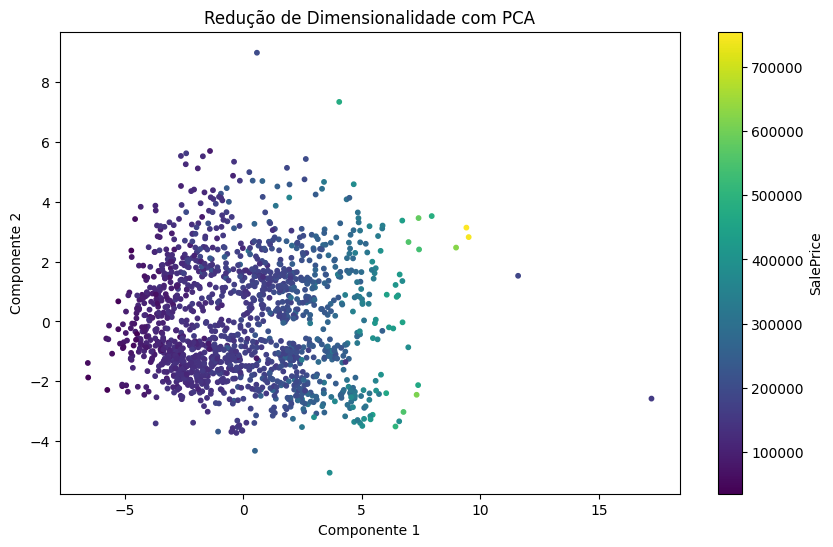

In [11]:
plt.figure(figsize=(10,6))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=df['SalePrice'], cmap='viridis', s=10)
plt.title('Redução de Dimensionalidade com PCA')
plt.xlabel('Componente 1')
plt.ylabel('Componente 2')
plt.colorbar(scatter, label='SalePrice')
plt.show()

<p>A técnica de Redução de Dimensionalidade com PCA (Análise de Componentes Principais) aplicada ao dataset permitiu transformar um conjunto de dados de alta dimensão em um espaço bidimensional, preservando ao máximo a variância dos dados.</p>

<p>No gráfico acima, os dois eixos representam os dois primeiros componentes principais, que concentram a maior parte da informação presente no conjunto original. Cada ponto representa uma observação (neste caso, imóveis), e a cor dos pontos varia conforme o valor da variável <em>SalePrice</em> (preço de venda).</p>

<p>É possível observar que as regiões do gráfico estão relacionadas a diferentes faixas de preço:</p>

<ul>
    <li>As áreas mais escuras (roxo e azul) concentram imóveis de menor valor.</li>
    <li>À medida que avançamos para a direita e para cima, os pontos adquirem tons mais claros (verde e amarelo), indicando imóveis com preços mais elevados.</li>
</ul>

<p>Isso demonstra que o PCA conseguiu, de maneira eficiente, reduzir a complexidade do dataset sem perder informações relevantes sobre a variável <em>SalePrice</em>. A separação dos pontos sugere que existe uma relação latente entre as características originais dos imóveis e o preço final, o que pode ser explorado em modelos de aprendizado de máquina ou em análises preditivas.</p>

<p>Além disso, nota-se uma maior dispersão dos imóveis mais caros, o que pode indicar que fatores específicos influenciam significativamente os preços mais elevados, tornando-os menos homogêneos em comparação com imóveis de menor valor.</p>


<h1>c. Análise de associação: Use o algoritmo Apriori para identificar associações entre as
características das casas.</h1>

<h2>Preparação e Tratamento de Dados</h2>

In [12]:
# Carrega o dataset
df = pd.read_csv("Data/train.csv")

# Selecionar colunas categóricas mais relevantes
selected_cols = [
    'MSZoning', 'Street', 'LotShape', 'LandContour',
    'Condition1', 'BldgType', 'HouseStyle', 'RoofStyle'
]

df_selected = df[selected_cols].fillna("Missing")

# Remover categorias muito raras (menos de 10 ocorrências)
for col in df_selected.columns:
    value_counts = df_selected[col].value_counts()
    rare_values = value_counts[value_counts < 10].index
    df_selected[col] = df_selected[col].apply(lambda x: "Other" if x in rare_values else x)

# Transformar em formato de transações (Ex: "MSZoning=RL")
transactions = df_selected.apply(lambda row: [f"{col}={val}" for col, val in row.items()], axis=1).tolist()

# One-hot encoding
te = TransactionEncoder()
te_array = te.fit(transactions).transform(transactions)
df_encoded = pd.DataFrame(te_array, columns=te.columns_)

<h2>Aplicação do Algoritmo Apriori</h2>

In [13]:
# Aplicar Apriori com suporte mínimo de 5%
frequent_itemsets = apriori(df_encoded, min_support=0.05, use_colnames=True)

# Gerar regras com confiança mínima de 70%
rules = association_rules(frequent_itemsets, metric="confidence", min_threshold=0.7)

# Exibir as 10 principais regras de associação
print(rules[['antecedents', 'consequents', 'support', 'confidence', 'lift']].head(10))

           antecedents        consequents   support  confidence      lift
0      (BldgType=1Fam)  (Condition1=Norm)  0.714384    0.854918  0.990619
1    (Condition1=Norm)    (BldgType=1Fam)  0.714384    0.827778  0.990619
2  (HouseStyle=1.5Fin)    (BldgType=1Fam)  0.097260    0.922078  1.103470
3  (HouseStyle=1Story)    (BldgType=1Fam)  0.415753    0.836088  1.000565
4  (HouseStyle=2Story)    (BldgType=1Fam)  0.247945    0.813483  0.973513
5      (BldgType=1Fam)  (LandContour=Lvl)  0.747945    0.895082  0.996811
6    (LandContour=Lvl)    (BldgType=1Fam)  0.747945    0.832952  0.996811
7       (LotShape=IR1)    (BldgType=1Fam)  0.300685    0.907025  1.085456
8       (LotShape=Reg)    (BldgType=1Fam)  0.502740    0.793514  0.949615
9      (BldgType=1Fam)      (MSZoning=RL)  0.702055    0.840164  1.065716


<p>O algoritmo Apriori foi aplicado ao dataset com o objetivo de identificar associações relevantes entre atributos dos imóveis, revelando padrões frequentes que podem ser úteis para compreensão do perfil dos imóveis e apoio à tomada de decisões.</p>

<p>A tabela acima apresenta as principais regras de associação extraídas, contendo as seguintes métricas:</p>

<ul>
    <li>Antecedents: Conjunto de itens que formam a condição inicial da regra.</li>
    <li>Consequents: Itens que tendem a ocorrer quando os antecedentes estão presentes.</li>
    <li>Support: Proporção de registros do dataset em que a combinação completa (antecedentes e consequentes) ocorre.</li>
    <li>Confidence: Probabilidade de o consequente ocorrer quando o antecedente está presente.</li>
    <li>Lift: Mede a força da associação, indicando o quanto a ocorrência conjunta dos itens é maior do que seria esperada pelo acaso (valores maiores que 1 indicam associação positiva).</li>
</ul>

<p>Algumas observações relevantes sobre as regras:</p>

<ul>
    <li>A associação entre <em>BldgType=1Fam</em> e <em>Condition1=Norm</em> apresenta suporte de aproximadamente 71% e confiança de 85%, o que indica que, na maioria das vezes em que o imóvel é do tipo "1Fam" (residencial unifamiliar), sua condição externa é considerada "Normal".</li>
    <li>A regra <em>HouseStyle=1.5Fin → BldgType=1Fam</em> apresenta uma confiança elevada de 92% e um lift superior a 1 (1.13), o que sugere uma associação positiva relevante: imóveis com estilo "1.5Fin" têm alta probabilidade de serem do tipo "1Fam".</li>
    <li>A associação <em>LotShape=IR1 → BldgType=1Fam</em> se destaca por apresentar o maior lift da análise, 1.085, reforçando que lotes com essa característica têm maior probabilidade de serem residências unifamiliares do que seria esperado aleatoriamente.</li>
    <li>De maneira geral, observa-se que muitas regras envolvem o atributo <em>BldgType=1Fam</em> como consequente, evidenciando o predomínio desse tipo de imóvel no dataset e sua forte relação com outros atributos estruturais e de localização.</li>
</ul>

<p>Essas informações podem auxiliar na segmentação do mercado imobiliário, identificação de perfis de imóveis e definição de estratégias de precificação ou construção, além de alimentar modelos preditivos mais precisos ao revelar dependências entre variáveis.</p>


<h1>d. Análise de outlier: Use o algoritmo Local Outlier Factor para identificar casas que podem ser
consideradas outliers</h1>

<h2>Preparação dos Dados</h2>

In [14]:
# Carrega o dataset
df = pd.read_csv("Data/train.csv")

# Selecionar colunas numéricas relevantes para a detecção de outliers
numeric_cols = ['LotArea', 'GrLivArea', 'TotalBsmtSF', '1stFlrSF', 'YearBuilt', 'OverallQual']
df_numeric = df[numeric_cols].dropna()

<h2>Aplicação do Algoritmo Outlier e Exibição do Resultados</h2>

In [15]:
# Aplicar o algoritmo Local Outlier Factor
lof = LocalOutlierFactor(n_neighbors=20)
outlier_labels = lof.fit_predict(df_numeric)
lof_scores = lof.negative_outlier_factor_

# Adicionar os resultados ao DataFrame
df_numeric['LOF_Score'] = lof_scores
df_numeric['Outlier'] = outlier_labels

# Selecionar os 10 maiores outliers (menores LOF scores)
top_outliers = df_numeric.nsmallest(10, 'LOF_Score')

top_outliers[['LOF_Score'] + numeric_cols]

,LOF_Score,LotArea,GrLivArea,TotalBsmtSF,1stFlrSF,YearBuilt,OverallQual
313,-9.468505,215245,2036,2136,2036,1965,7
335,-7.040282,164660,1786,1499,1619,1965,5
249,-6.774063,159000,2144,1444,1444,1958,6
706,-4.864952,115149,1824,1643,1824,1971,7
332,-2.886345,10655,1629,3206,1629,2003,8
451,-2.865184,70761,1533,1533,1533,1975,7
1044,-2.741315,9600,2524,2524,2524,1981,8
1298,-2.523814,63887,5642,6110,4692,2008,10
496,-2.488274,12692,3228,3200,3228,1992,8
778,-2.357562,8400,2020,0,2020,1977,5


<p>Foi aplicado o algoritmo LOF (Local Outlier Factor) no dataset com o objetivo de identificar observações que se comportam de forma anômala em relação à vizinhança, ou seja, potenciais <em>outliers</em>.</p>

<p>Na tabela acima, são apresentados os 10 imóveis com os menores valores de LOF_Score, o que indica forte probabilidade de serem considerados outliers. Quanto menor (mais negativo) o valor do <em>LOF_Score</em>, maior o grau de anomalia detectado.</p>

<h3>Principais Observações:</h3>

<ul>
    <li>O imóvel de índice 313 apresenta o menor <em>LOF_Score</em> (-9.46), sendo um forte candidato a outlier. Ele possui uma área do lotemuito elevada (215.245) em comparação com o restante do conjunto, o que provavelmente motivou sua classificação como anômalo.</li>
    <li>Os imóveis de índices 335 e 249 também se destacam por áreas do lote consideravelmente superiores à média, o que foge do padrão típico observado no dataset.</li>
    <li>Outro fator que contribui para a detecção de outliers são discrepâncias nas áreas internas, como no caso do imóvel de índice 1298, que apresenta área total de porão (<em>TotalBsmtSF</em>) e área do primeiro andar (<em>1stFlrSF</em>) muito elevadas, além de uma excelente <em>OverallQual</em> de 10, o que pode torná-lo uma propriedade atípica no contexto geral.</li>
    <li>O imóvel de índice 778 chama atenção por possuir <em>TotalBsmtSF</em> igual a zero, o que pode indicar ausência de porão ou inconsistência no preenchimento dos dados, fator que também contribui para sua classificação como anômalo.</li>
</ul>